# Lab 02: Credit Ratings

---
author: Isabella Iniguez
date: September 25, 2024
embed-resources: true
---

## Introduction

In this report, we develop a regression model that predicts the credit rating for an individual based on income and demographic information. By building this model, we would be able to save the bank money by avoiding the costs of relying on credit agencies to provide customer credit ratings.

## Methods

In [120]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Data

In [121]:
# load data
credit_train = pd.read_csv("https://cs307.org/lab-02/data/credit-train.csv")
credit_test = pd.read_csv("https://cs307.org/lab-02/data/credit-test.csv")
credit_train

,Rating,Income,Age,Education,Gender,Student,Married,Ethnicity
0,257.0,44.473,81.0,16.0,Female,No,No,NaN
1,353.0,41.532,50.0,NaN,Male,No,Yes,Caucasian
2,388.0,16.479,26.0,16.0,Male,NaN,No,NaN
3,321.0,10.793,29.0,13.0,Male,No,No,Caucasian
4,367.0,76.273,65.0,14.0,Female,No,Yes,Caucasian
...,...,...,...,...,...,...,...,...
251,268.0,26.370,78.0,11.0,Male,No,Yes,Asian
252,433.0,26.427,50.0,15.0,Female,Yes,Yes,Asian
253,259.0,12.031,58.0,18.0,Female,NaN,Yes,Caucasian
254,335.0,80.861,29.0,15.0,Female,No,Yes,Asian


### Data Dictionary

The `Train` data contains one row per banking customer located in the United States.

The `Test` data contains one row per banking customer located in the United States.

The variables considered are:

#### Response

`Rating`

-   `[float64]` credit rating, specifically the credit score of an individual consumer

#### Features

`Income`	

-   `[int64]` yearly income in $1000s

`Age`	

-   `[int64]` age

`Education`	

-   `[int64]` years of education completed

`Gender`

-   `[object]` gender

`Student`

-   `[object]` a Yes / No variable with Yes indicating an individual is a student

`Married`

-   `[object]` a Yes / No variable with Yes indicating an individual is married

`Ethnicity`

-   `[object]` ethnicity

In [122]:
# summary statistics
# Rating (Target) Statistics
print("Rating Mean: ", credit_train["Rating"].mean())
print("Rating Standard Deviation: ", credit_train["Rating"].std())

Rating Mean:  347.609375
Rating Standard Deviation:  148.8931046679028


In [123]:
# Rating Statistics Based on Student Status
m = credit_train[["Student","Rating"]].groupby("Student").agg('mean').rename(columns={'Rating':'mean'})
s = credit_train[["Student","Rating"]].groupby("Student").agg('std').rename(columns={'Rating':'std'})
c = credit_train[["Student","Rating"]].groupby("Student").agg('count').rename(columns={'Rating':'count'})
m.join(s).join(c)

,mean,std,count
Student,,,
No,349.511737,148.003525,213
Yes,338.473684,149.164476,19


In [124]:
# Rating Statistics Based on Marriage Status
m = credit_train[["Married","Rating"]].groupby("Married").agg('mean').rename(columns={'Rating':'mean'})
s = credit_train[["Married","Rating"]].groupby("Married").agg('std').rename(columns={'Rating':'std'})
c = credit_train[["Married","Rating"]].groupby("Married").agg('count').rename(columns={'Rating':'count'})
m.join(s).join(c)

,mean,std,count
Married,,,
No,329.397959,132.039649,98
Yes,358.905063,157.797935,158


In [125]:
# Correlation with Target
credit_train[["Age","Income","Rating"]].corr()

,Age,Income,Rating
Age,1.000000,0.202098,0.143032
Income,0.202098,1.000000,0.770842
Rating,0.143032,0.770842,1.000000


In [126]:
# Missing Data
credit_train.isna().sum() / len(credit_train)

Rating       0.000000
Income       0.000000
Age          0.128906
Education    0.097656
Gender       0.023438
Student      0.093750
Married      0.000000
Ethnicity    0.097656
dtype: float64

Text(0.5, 0, 'Education')

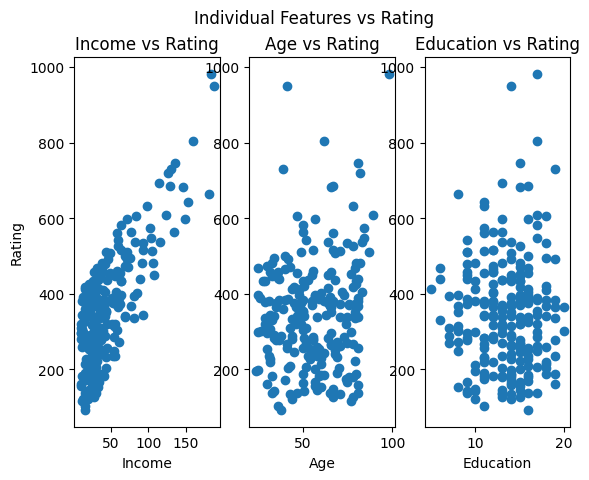

In [127]:
# visualizations
fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.suptitle('Individual Features vs Rating')

ax1.scatter(credit_train["Income"], credit_train["Rating"])
ax1.set_title('Income vs Rating')
ax1.set_xlabel("Income")
ax1.set_ylabel("Rating")

ax2.scatter(credit_train["Age"], credit_train["Rating"])
ax2.set_title('Age vs Rating')
ax2.set_xlabel("Age")

ax3.scatter(credit_train["Education"], credit_train["Rating"])
ax3.set_title('Education vs Rating')
ax3.set_xlabel("Education")

/var/folders/6m/my9t42v50nd_m2zp_5rf230r0000gn/T/ipykernel_931/1271728286.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 0].boxplot(data, labels=['Female', 'Male'])
/var/folders/6m/my9t42v50nd_m2zp_5rf230r0000gn/T/ipykernel_931/1271728286.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, 1].boxplot(data, labels=['No', 'Yes'])
/var/folders/6m/my9t42v50nd_m2zp_5rf230r0000gn/T/ipykernel_931/1271728286.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, 0].boxplot(data, labels=['No', 'Yes'])
/var/folders/6m/my9t42v50nd_m2zp_5rf230r0000gn/T/ipykernel_931/1271728286.py:26: MatplotlibDeprecation

Text(0.5, 0, 'Ethnicity')

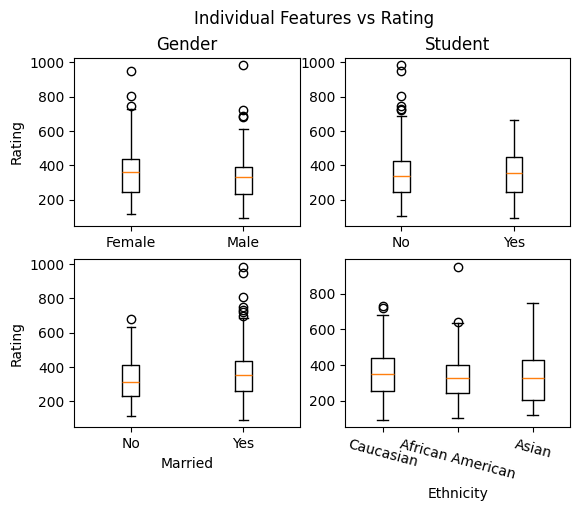

In [128]:
fig, axs = plt.subplots(2, 2)
fig.suptitle('Individual Features vs Rating')

data = [credit_train[credit_train["Gender"]=="Female"]["Rating"], credit_train[credit_train["Gender"]==" Male"]["Rating"]]
axs[0, 0].boxplot(data, labels=['Female', 'Male'])
# axs[0, 0].set_title('Gender vs Rating')
axs[0, 0].set_ylabel('Rating')
# axs[0, 0].set_xlabel("Gender")
axs[0, 0].set_title('Gender')

data = [credit_train[credit_train["Student"]=="No"]["Rating"], credit_train[credit_train["Student"]=="Yes"]["Rating"]]
axs[0, 1].boxplot(data, labels=['No', 'Yes'])
# axs[0, 1].set_title('Student vs Rating')
# axs[0, 1].set_xlabel("Student")
axs[0, 1].set_title('Student')

data = [credit_train[credit_train["Married"]=="No"]["Rating"], credit_train[credit_train["Married"]=="Yes"]["Rating"]]
axs[1, 0].boxplot(data, labels=['No', 'Yes'])
# axs[1, 0].set_title('Married vs Rating')
axs[1, 0].set_ylabel('Rating')
axs[1, 0].set_xlabel("Married")

data = [credit_train[credit_train["Ethnicity"]=="Caucasian"]["Rating"], 
        credit_train[credit_train["Ethnicity"]=="African American"]["Rating"],
        credit_train[credit_train["Ethnicity"]=="Asian"]["Rating"]]
axs[1, 1].boxplot(data, labels=['Caucasian', 'African American', 'Asian'])
axs[1, 1].set_xticklabels(['Caucasian', 'African American', 'Asian'], rotation=-15)
# axs[1, 1].set_title('Ethnicity vs Rating')
axs[1, 1].set_xlabel("Ethnicity")

Breaking down the data by each feature's relation to the Rating, we notice a few trends. 

The income feature appears to be the most strongly positively correlated to credit rating, as higher income levels consistently yield a higher rating by the scatterplot and the high correlation coefficient of 0.77.

Other catergorical features such as gender, marital status, student status, and ethnicity provide some dispersion in ratings but with similar medians for each category. Some of the dispersion comes with varying ranges, such as how female customers tend to have a higher range of credit ratings than male customers. Others come from outliers, such as how married customers have a slightly higher range of credit ratings, but expecially so when considering the outliers.

So in predicting credit ratings, numerical features like income are likely to be highly influential whereas most of the categorical features may be more nuanced.

There is also missing data, which we should plan to handle when finding our model.

### Models

In [129]:
# process data for ML
# create X and y for train
X_train = credit_train.drop("Rating", axis=1)
y_train = credit_train["Rating"]

# create X and y for test
X_test = credit_test.drop("Rating", axis=1)
y_test = credit_test["Rating"]

In [130]:
# note numeric and categorical features
numeric_features = ["Income", "Age", "Education"]
categorical_features = ["Gender","Student","Married","Ethnicity"]

# define preprocessing for numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
    ]
)

# define preprocessing for categorical features
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder()),
    ]
)

# combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# create pipeline, preprocess then classify
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", KNeighborsRegressor()),
    ]
)

In [131]:
pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age',
                                                   'Education']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder())]),
                                                  ['Gender', 'Student',
                                                   'Married', 'Ethnicity'])])),
                ('regressor', KNeighborsRegressor())])

In [132]:
# define parameter grid
param_grid = {
    "preprocessor__cat__onehot__drop": [None, "first"],
    "preprocessor__num__scaler": [None, StandardScaler()],
    "regressor__n_neighbors": [3, 5, 7, 9, 11],
    "regressor__metric": ["euclidean", "manhattan"],
}

In [133]:
# setup grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="neg_root_mean_squared_error")

In [134]:
# run grid search with cross-validation
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer()),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Income',
                                                                          'Age',
                                                                          'Education']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder())]),
                                                                         ['Gender',
                                                                          'Student',
                                                                          'Married',
                                                                          'Ethnicity'])])),
                                       ('regressor', KNeighborsRegressor())]),
             param_grid={'preprocessor__cat__onehot__drop': [None, 'first'],
                         'preprocessor__num__scaler': [None, StandardScaler()],
                         'regressor__metric': ['euclidean', 'manhattan'],
                         'regressor__n_neighbors': [3, 5, 7, 9, 11]},
             scoring='neg_root_mean_squared_error')

In [135]:
# print best parameters found and best (cross-validated) score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation rmse: {grid_search.best_score_}")

Best parameters: {'preprocessor__cat__onehot__drop': None, 'preprocessor__num__scaler': None, 'regressor__metric': 'manhattan', 'regressor__n_neighbors': 11}
Best cross-validation rmse: -102.99659531570259


Here we used a tuning pipeline to try and find the best cross-validated KNN reggression model.

## Results

In [136]:
# final evaluation on test set
y_pred = grid_search.predict(X_test)
print(f"Test set rmse: {root_mean_squared_error(y_test, y_pred)}")

Test set rmse: 101.1089231160024


The selected model achieve a test rmse of 101.11.

## Discussion

Given the range of credit rating (0 to 1000), a test RMSE of 101.1 is indicative of a fairly large error and this model not being a good predictor of credit rating. However, even if the model displayed adequate performance, the performance metric alone does not determine whether the model is suitable for real banking use. While a tuning pipeline with cross-validation can help optimize KNN's parameters and improve it's performance, credit scoring has immense, direct influences on customers's financial opportunities so you have to consider the ethical and legal ramifications of its use.

One concern is the use of certain demographic features. Including variables such as race, gender, marital status, or age as determining variables in our model can be discriminatory. These features might introduce biases into the decision-making process, perpetuating unfair impacts on marginalized groups. This would not only be unethical but could also lead the bank into some legal challenges as this might violate possible legal frameworks that prohibit the use of demographic information in credit decisions. A more ideal model would use fair and non-discriminatory features, such as credit history or financial behavior.

### Conclusion

Given the unimpressive performance, together with the other potential issues mentioned, I do not recommend this model for use in practice.

In [137]:
from joblib import dump
dump(grid_search, "credit-ratings.joblib")

['credit-ratings.joblib']